Storms in cleaned file: 115


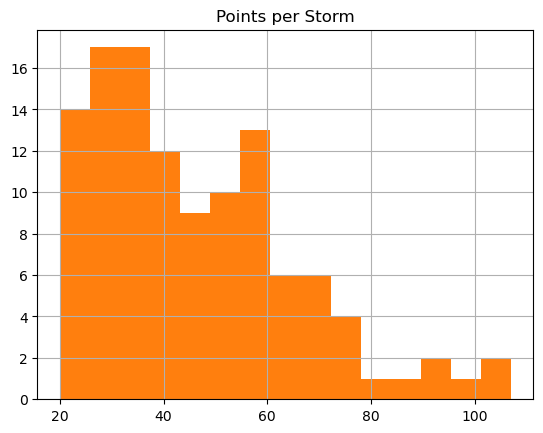

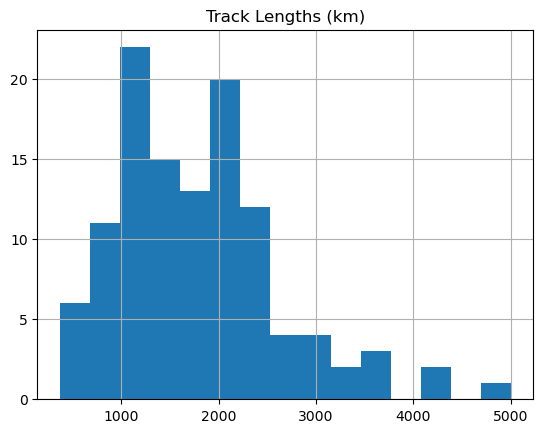

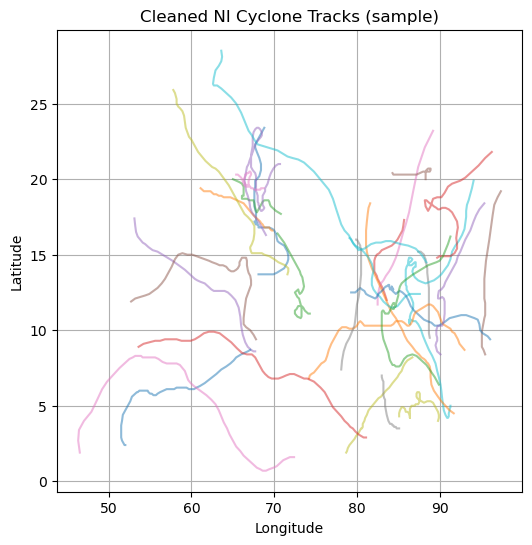

{'NI'}
Any invalid wind? False
Points per storm:
 count    115.000000
mean      46.173913
std       18.976098
min       20.000000
25%       31.000000
50%       43.000000
75%       59.000000
max      107.000000
dtype: float64
Max wind per storm (kt):
 count    115.000000
mean      65.565217
std       33.012260
min       30.000000
25%       40.000000
50%       55.000000
75%       85.000000
max      150.000000
dtype: float64
SSHS categories (0=TS, 1–5=Cat):
 0    71
1    13
2     7
3     9
4     9
5     6
Name: count, dtype: int64
Storms per year:
 2001    4
2002    5
2003    3
2004    5
2005    6
2006    5
2007    5
2008    7
2009    4
2010    4
2011    6
2012    4
2013    5
2014    5
2015    5
2016    4
2017    3
2018    4
2019    7
2020    5
2021    5
2022    7
2023    7
Name: count, dtype: int64


In [22]:
from climada.hazard import TCTracks

clean_file = r"C:\CMIP data\cmip6\Climada\Projects\ccart-india\data\ni_tracks_climada_1950_2023_cleaned.h5"
tracks_clean = TCTracks.from_hdf5(clean_file)

storms = tracks_clean.data
print("Storms in cleaned file:", len(storms))

import pandas as pd

points_per_storm = [len(s.time) for s in storms]
pd.Series(points_per_storm).describe()

pd.Series(points_per_storm).hist(bins=15)

from haversine import haversine
import numpy as np

def track_length_km_clean(storm, max_jump_km=300):
    df = storm.to_dataframe()
    coords = list(zip(df.lat, df.lon))
    dist = 0
    for (lat1, lon1), (lat2, lon2) in zip(coords[:-1], coords[1:]):
        d = haversine((lat1, lon1), (lat2, lon2))
        if d < max_jump_km:
            dist += d
    return dist

track_lengths = [track_length_km_clean(s) for s in storms]
pd.Series(points_per_storm).hist(bins=15)
plt.title("Points per Storm")
plt.show()

pd.Series(track_lengths).hist(bins=15)
plt.title("Track Lengths (km)")
plt.show()


max_wind_per_storm = [
    float(s.max_sustained_wind.max())
    for s in storms
]
pd.Series(max_wind_per_storm).describe()

def sshs_category(wind):
    if wind < 64:   return 0
    elif wind < 83: return 1
    elif wind < 96: return 2
    elif wind < 113:return 3
    elif wind < 137:return 4
    else:           return 5

cats = [sshs_category(w) for w in max_wind_per_storm]
pd.Series(cats).value_counts().sort_index()

years = [
    int(s.time.dt.year.min().item())
    for s in storms
]
pd.Series(years).value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for s in storms[:30]:  # first 30 storms
    df = s.to_dataframe()
    plt.plot(df.lon, df.lat, alpha=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Cleaned NI Cyclone Tracks (sample)")
plt.grid(True)
plt.show()

basins = set(
    s.basin.values[0] if hasattr(s, "basin") else s.to_dataframe().basin.iloc[0]
    for s in storms
)
print(basins)

import numpy as np

any_invalid = any(
    (s.max_sustained_wind.values <= 0).any() or np.isnan(s.max_sustained_wind.values).any()
    for s in storms
)
print("Any invalid wind?", any_invalid)


pts_stats = pd.Series(points_per_storm).describe()
print("Points per storm:\n", pts_stats)


wind_stats = pd.Series(max_wind_per_storm).describe()
print("Max wind per storm (kt):\n", wind_stats)

cat_counts = pd.Series(cats).value_counts().sort_index()
print("SSHS categories (0=TS, 1–5=Cat):\n", cat_counts)

year_counts = pd.Series(years).value_counts().sort_index()
print("Storms per year:\n", year_counts)


